# Phase 1: Data Exploration for Total Perspective Vortex
This notebook explores the PhysioNet EEG Motor Movement/Imagery Dataset. 

**Motor Execution vs. Motor Imagery:**
* **Motor Execution (ME):** The subject physically performs a movement (e.g., opening/closing a fist). This generates actual sensory-motor cortex activation.
* **Motor Imagery (MI):** The subject *imagines* performing the movement without any actual muscle activity. This is the core of our BCI pipeline. We aim to detect the Event-Related Desynchronization/Synchronization (ERD/ERS) in the alpha and beta bands that occurs during the *thought* of movement.

In [7]:
import os

In [8]:
print(os.getcwd())

/Users/alex/brige-projects/programing/42/projects/Total-Perspective-Vortex/doc


In [9]:

from misc  import *

## 1.  load the data

In [10]:

# 1. Load the data
raw = load_eeg_data(SUBJECT_TO_TEST, RUN_TO_TEST)


Loading data from ./data/files/S001/S001R03.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.


## 2. Extract and map events

In [11]:

# 2. Map the events
events, event_dict, event_descriptions = extract_and_map_events(raw, RUN_TO_TEST)


Mapped Events for Run 3:
  Code 1: Rest (T0)
  Code 2: Opening/closing left fist (T1)
  Code 3: Opening/closing right fist (T2)


In [12]:
# Example to explore the first 5 events data structure 

events[:5]
# e.g [[time(in seconds), 0, event_code], ...] 

array([[   0,    0,    1],
       [ 672,    0,    3],
       [1328,    0,    1],
       [2000,    0,    2],
       [2656,    0,    1]])

In [13]:
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

## Visualize the raw signals and plot the 3D scalp representation of the electrodes in MNE-Python

In [14]:
# retreive the 3D EEG data for subject 1, run 4
  # with the standard_1005 montage for better spatial representation
raw_3d_ex = load_eeg_data(1, 4, base_path=BASE_DATA_PATH, montage_type="standard_1005")

Loading data from ./data/files/S001/S001R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1005 montage applied.


In [15]:
raw_3d_ex.info

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

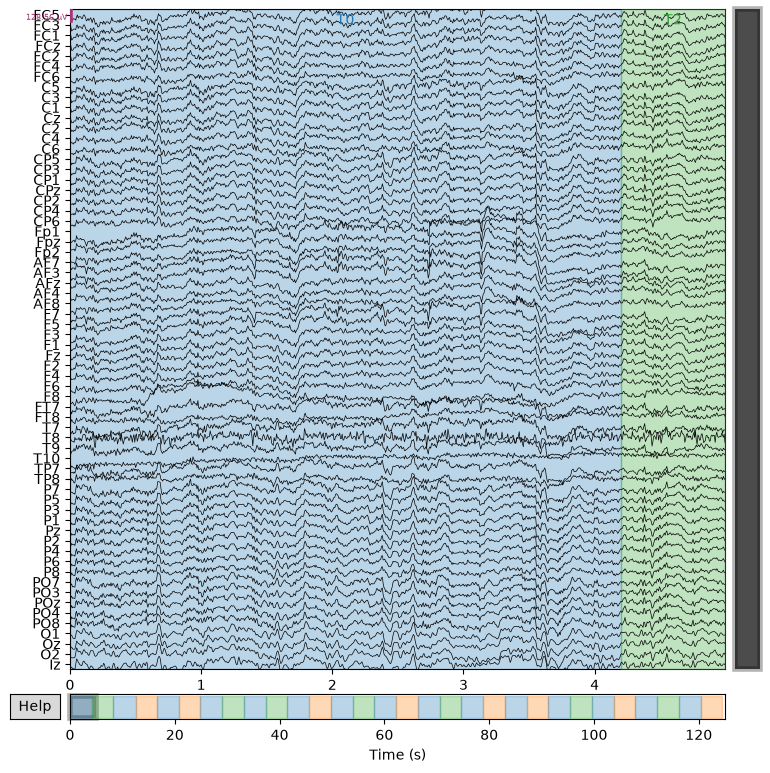

In [16]:
# Cell 4: Plotting the raw signals
# We specify n_channels=64 to see everything at once.
# duration=5.0 shows 5 seconds of data on the screen at a time.
# scalings='auto' automatically adjusts the vertical scale so the waves don't overlap too much.

fig_signals = raw_3d_ex.plot(
    n_channels=64, # we show all 64 channels at once
    duration=5.0, # it plots the first 5 seconds of data
    scalings="auto",
    title="Raw EEG Signals - All 64 Channels",
)

# Note: If you are using an interactive backend, you can use your arrow keys
# to scroll left and right through the timeline!

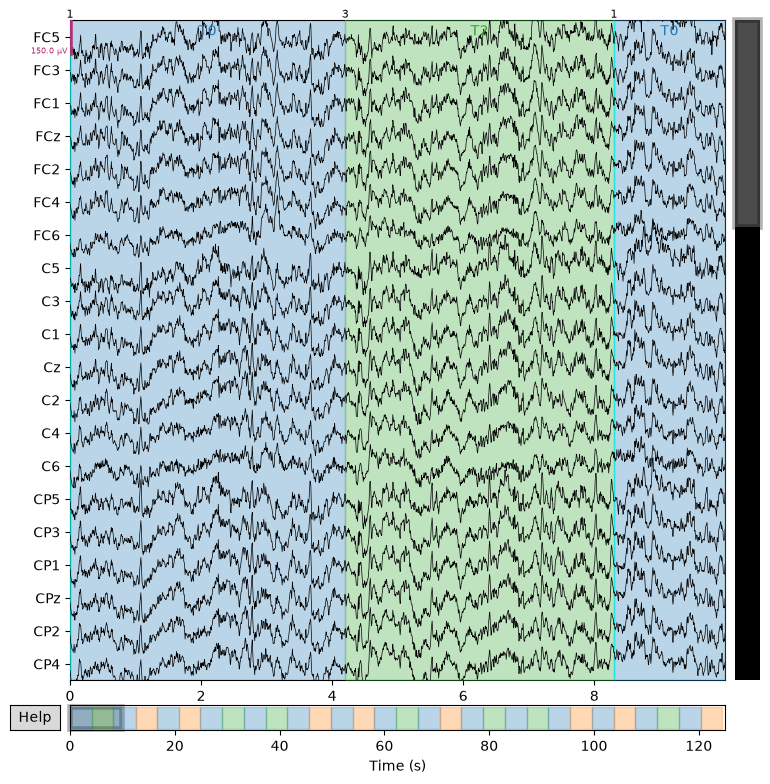

In [29]:



# 3. Visualize Raw Continuous Signal with Events
# Note: In a Jupyter Notebook, %matplotlib widget or qt can make this fully interactive.
# We set scalings='auto' or a specific microvolt dictionary so signals don't overlap.
fig_raw = raw.plot(
    events=events, 
    start=0, 
    duration=10, # it plots the first 10 seconds of data 
    # n_channels sets how many channels to display at once; adjust for visibility
    n_channels=20, 
    scalings={'eeg': 75e-6}, # Scale to 75 microvolts for better visibility
    title=f"Subject {SUBJECT_TO_TEST} Run {RUN_TO_TEST} - Raw EEG (First 10s)",
    show=True
)

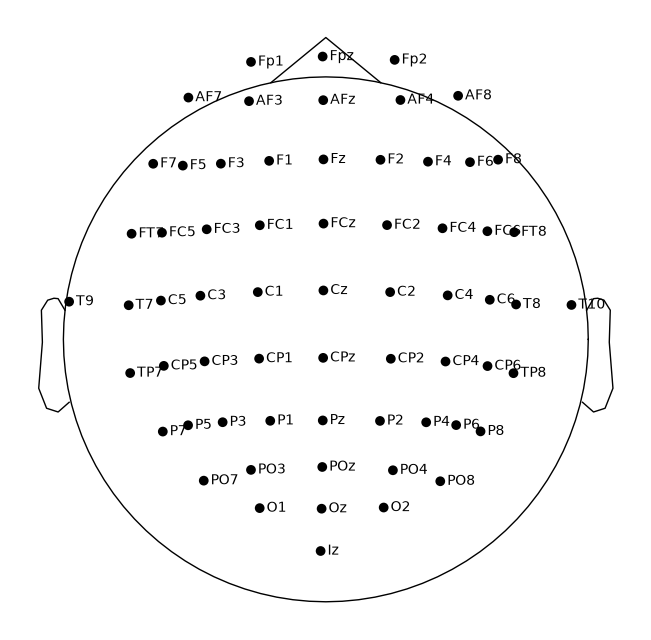

In [17]:
# Cell 5: Plotting the 3D Scalp representation
# kind='3d' generates the 3D sphere/head model.
# show_names=True prints the channel labels (e.g., 'Cz', 'Pz') next to the dots.
# !ch_type: 'eeg' specifies that we want to visualize EEG channels specifically.
# !show_names: True ensures that the channel names are displayed on the 3D plot.
fig_3d = raw_3d_ex.plot_sensors(kind='topomap', ch_type="eeg", show_names=True)

# Note: In an interactive notebook, you can click and drag this image to rotate the 3D head!

## Power Spectral Density (PSD) Analysis
* We can compute the PSD to see how power is distributed across frequencies.
* The PSD is computed using Welch's method, which averages periodograms to reduce noise. 

/Users/alex/brige-projects/programing/42/projects/Total-Perspective-Vortex/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


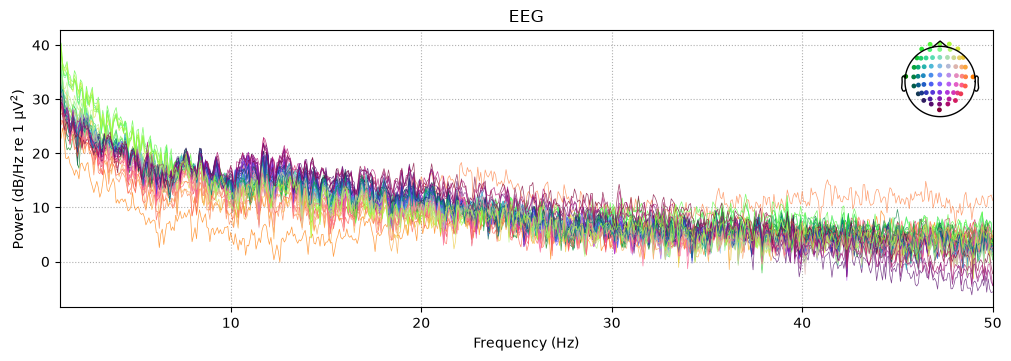

<Figure size 2000x500 with 0 Axes>

In [ ]:

# 4. Visualize Power Spectral Density (PSD)
# We limit frequencies between 1 Hz and 50 Hz to focus on Alpha (8-13 Hz) and Beta (14-30 Hz)
# because these bands are the most relevant for congnitive state analysis due to the fact that they are the most prominent or significant in EEG signals.
# This is crucial for feature selection in Phase 1.
# !fmin:  means the minimum frequency to include in the PSD calculation
# ! fmax:  means the maximum frequency to include in the PSD calculation
fig_psd = raw.compute_psd(fmin=1.0, fmax=50.0).plot(
    # picks means which channels to include in the PSD calculation. 
        # 'eeg' includes all EEG channels.
    picks='eeg', 
    # exclude means which channels to exclude from the PSD calculation. 
        # 'bads' includes all channels marked as bad in the raw.info['bads'] list.
    exclude='bads',
    show=True
)

# Add supplementary static visualization of event timing using Matplotlib
# sizefigure=(20, 5) sets the figure size to 20 inches wide and 5 inches tall.
plt.figure(figsize=(20, 5))
plt.show()

### 1. The Axes

* **X-Axis (Frequency in Hz):** Represents the frequency of the brainwaves, ranging from 0 to 50 Hz. Different frequency bands correspond to distinct cognitive states <span style="color: red;"><b>(e.g., Alpha is 8–12 Hz, Beta is 13–30 Hz)</b></span>.

* **Y-Axis (Power in dB/Hz):** This measures the strength or "loudness" of the signal at that specific frequency. It is on a logarithmic scale (decibels) because lower frequencies naturally have vastly higher power than high frequencies.

### 2. The Lines and the Head Map (Inset)

* Every single squiggly line represents one of your 64 electrodes.
* The small head model in the top right is your color legend. The color of a line corresponds to its physical location on the scalp. For example:
* **Green/Yellow lines:** Frontal electrodes (near the forehead).
* **Purple/Dark Blue lines:** Occipital/Parietal electrodes (at the back of the head).



### 3. Key Takeaways from the Data Shape

* **The 1/f Drop-off:** Notice how all the lines start very high on the left and curve downward as they move right. This is a universal characteristic of human brainwaves; slow waves carry the most amplitude, and fast waves carry the least.
* **The Alpha Peak (~10 Hz):** Look closely at the 10 to 12 Hz mark. You will see a distinct "hump" or peak that interrupts the downward curve, particularly in the purple and dark pink lines. This is the **Alpha rhythm**. Because it is strongest in the purple channels, it tells us the subject had high visual relaxation (Alpha waves are strongest in the visual cortex at the back of the head when resting or eyes are closed).
